In [ ]:
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const
from astropy import units as u

solar_radius = const.R_sun
solar_mass = const.M_sun
gravitactional_constant = const.G
solar_mass = const.M_sun
k_b = const.k_B
mass_electron = const.m_e
sigma = const.sigma_sb
c = const.c
a = 4 * sigma / c

os.makedirs('images', exist_ok=True)

# 2A. Busque el modelo de Jørgen Christensen Dalsgaard

entre al enlace "Limited set of variables for model S". https://users-phys.au.dk/jcd/solar_models/ Calcule y grafique M(r) versus el radio. Puede hacerlo en forma adimensional como está allí. Calcule luego el valor absoluto de la energía potencial gravitacional. Cuál es su valor en unidades SI? Si 

$$- \Omega_{\star}=q \frac{G M_{\star}^2}{R_{\star}} $$

en donde $q>0$ es un número real. Cuál es el valor de $q$?


In [2]:
df = pd.read_csv('data/data.txt',sep=' ',skiprows=5,header=None)   
df.drop([0,5],axis=1,inplace=True)
df.columns = ['r/R', 'c (cm/sec)', 'rho (g/cm^3)', 'p (dyn/cm^2)', 'Gamma_1', 'T (K)']
# radius sound speed, density, pressure, adiabatic exponent and temperature
df = df.iloc[::-1] #flip the dataframe to have the center of the sun at the top and the surface at the bottom
df.reset_index(drop=True,inplace=True) 
df.head()

,r/R,c (cm/sec),rho (g/cm^3),p (dyn/cm^2),Gamma_1,T (K)
0,0.000000,50465569.0,153.88936,2.349248e+17,1.668285,15668470.0
1,0.001391,50466228.0,153.86501,2.348937e+17,1.668284,15667793.0
2,0.001410,50466228.0,153.86447,2.348929e+17,1.668285,15667775.0
3,0.001429,50466263.0,153.86369,2.348920e+17,1.668284,15667756.0
4,0.001448,50466295.0,153.86289,2.348911e+17,1.668285,15667737.0


In [3]:
# setting units
df['c (cm/sec)'] = df['c (cm/sec)'].apply(lambda x: x * u.cm/u.s)
df['rho (g/cm^3)'] = df['rho (g/cm^3)'].apply(lambda x: x * u.g / u.cm**3)
df['p (dyn/cm^2)'] = df['p (dyn/cm^2)'].apply(lambda x: x * u.dyn/u.cm**2) 
df['T (K)'] = df['T (K)'].apply(lambda x: x * u.K)

In [4]:
df['rho (kg/m^3)'] = df['rho (g/cm^3)'].apply(lambda x: x.to(u.kg/u.m**3))
df['r'] = df['r/R'] * solar_radius.to(u.m)
df['r'] = df['r'].apply(lambda x: x*u.m)
df['dr'] = df['r'].diff()

In [5]:
df.loc[0,'dr']  = 0 * u.m
df

,r/R,c (cm/sec),rho (g/cm^3),p (dyn/cm^2),Gamma_1,T (K),rho (kg/m^3),r,dr
0,0.000000,50465569.0 cm / s,153.88936 g / cm3,2.3492475e+17 dyn / cm2,1.668285,15668470.0 K,153889.36 kg / m3,0.0 m,0.0 m
1,0.001391,50466228.0 cm / s,153.86501 g / cm3,2.3489373e+17 dyn / cm2,1.668284,15667793.0 K,153865.01 kg / m3,967788.2699999999 m,967788.2699999999 m
2,0.001410,50466228.0 cm / s,153.86447 g / cm3,2.3489289e+17 dyn / cm2,1.668285,15667775.0 K,153864.47 kg / m3,980797.86 m,13009.590000000084 m
3,0.001429,50466263.0 cm / s,153.86369 g / cm3,2.3489205e+17 dyn / cm2,1.668284,15667756.0 K,153863.68999999997 kg / m3,994016.16 m,13218.300000000047 m
4,0.001448,50466295.0 cm / s,153.86289 g / cm3,2.3489111e+17 dyn / cm2,1.668285,15667737.0 K,153862.88999999998 kg / m3,1007373.6000000001 m,13357.44000000006 m
...,...,...,...,...,...,...,...,...,...
2477,1.000681,686977.49 cm / s,4.0668379e-09 g / cm3,1167.9998 dyn / cm2,1.643233,4349.5866 K,4.0668379e-06 kg / m3,696173562.99 m,5635.170000076294 m
2478,1.000689,686840.63 cm / s,3.8555865e-09 g / cm3,1107.3017 dyn / cm2,1.642618,4349.1832 K,3.855586499999999e-06 kg / m3,696179198.1600001 m,5635.170000076294 m
2479,1.000697,686706.53 cm / s,3.6565446e-09 g / cm3,1050.1248 dyn / cm2,1.641997,4348.8194 K,3.6565445999999996e-06 kg / m3,696184763.76 m,5565.599999904633 m
2480,1.000705,686573.05 cm / s,3.4690527e-09 g / cm3,996.27728 dyn / cm2,1.641361,4348.4914 K,3.4690527e-06 kg / m3,696190259.79 m,5496.02999997139 m


Se caclula $M(r)$ utilizando la ecucaion de continuidad de la masa $dM(r) = 4\pi r² dr$ y luego sumando los $dM(r)$ donde $dr$ se caclulo como la diferencia del radio en metros de la fila anterior con el comando diff

In [6]:
df['dM(r)'] = (4* np.pi * df['r']**2 * df['rho (kg/m^3)'] * df['dr'] )
df['M(r)'] = df['dM(r)'].cumsum()
df

,r/R,c (cm/sec),rho (g/cm^3),p (dyn/cm^2),Gamma_1,T (K),rho (kg/m^3),r,dr,dM(r),M(r)
0,0.000000,50465569.0 cm / s,153.88936 g / cm3,2.3492475e+17 dyn / cm2,1.668285,15668470.0 K,153889.36 kg / m3,0.0 m,0.0 m,0.0 kg,0.0 kg
1,0.001391,50466228.0 cm / s,153.86501 g / cm3,2.3489373e+17 dyn / cm2,1.668284,15667793.0 K,153865.01 kg / m3,967788.2699999999 m,967788.2699999999 m,1.752632235886044e+24 kg,1.752632235886044e+24 kg
2,0.001410,50466228.0 cm / s,153.86447 g / cm3,2.3489289e+17 dyn / cm2,1.668285,15667775.0 K,153864.47 kg / m3,980797.86 m,13009.590000000084 m,2.4197518931122568e+22 kg,1.7768297548171666e+24 kg
3,0.001429,50466263.0 cm / s,153.86369 g / cm3,2.3489205e+17 dyn / cm2,1.668284,15667756.0 K,153863.68999999997 kg / m3,994016.16 m,13218.300000000047 m,2.525273967614306e+22 kg,1.8020824944933096e+24 kg
4,0.001448,50466295.0 cm / s,153.86289 g / cm3,2.3489111e+17 dyn / cm2,1.668285,15667737.0 K,153862.88999999998 kg / m3,1007373.6000000001 m,13357.44000000006 m,2.6208858857663625e+22 kg,1.8282913533509733e+24 kg
...,...,...,...,...,...,...,...,...,...,...,...
2477,1.000681,686977.49 cm / s,4.0668379e-09 g / cm3,1167.9998 dyn / cm2,1.643233,4349.5866 K,4.0668379e-06 kg / m3,696173562.99 m,5635.170000076294 m,1.3957537474637923e+17 kg,1.9853403343138876e+30 kg
2478,1.000689,686840.63 cm / s,3.8555865e-09 g / cm3,1107.3017 dyn / cm2,1.642618,4349.1832 K,3.855586499999999e-06 kg / m3,696179198.1600001 m,5635.170000076294 m,1.3232729110187694e+17 kg,1.98534033431402e+30 kg
2479,1.000697,686706.53 cm / s,3.6565446e-09 g / cm3,1050.1248 dyn / cm2,1.641997,4348.8194 K,3.6565445999999996e-06 kg / m3,696184763.76 m,5565.599999904633 m,1.2394863777212363e+17 kg,1.9853403343141437e+30 kg
2480,1.000705,686573.05 cm / s,3.4690527e-09 g / cm3,996.27728 dyn / cm2,1.641361,4348.4914 K,3.4690527e-06 kg / m3,696190259.79 m,5496.02999997139 m,1.1612500398850363e+17 kg,1.98534033431426e+30 kg


In [ ]:
from utilities.ploting import plot_data

data = df[['r/R', 'M(r)']].copy()
data['M(r)'] = data['M(r)'].apply(lambda x: x.to(u.kg).value)

plot_data(
    data, 'r/R', ['M(r)'],
    labels=['Mass enclosed within radius r'], 
    xlabel=r'relative Radius ($r/R_\odot$)', 
    ylabel='Mass (kg)', 
    title='Distribucion de masa del sol',
    show_legend=False,
    savepath='images/mass_distribution.png'
    );
 
del data

se nota que la grafica conside con la teoria ya que se ve como la partes mas exteiores del sol son menos densas ya que la presion ahi ya no es tan alta y son las partes centrales por debajo de la mitad del radio las que tienen mas densidad.

se sabe que la enegia potencial gravitacional se define como 

$$d\Omega_r = \int_\infin^r G M(r)dM(r)\frac{dr'}{r'^2} = - \frac{GM(r)dM(r)}{r}$$

In [8]:
#df['dOmega'] = -gravitactional_constant*(df['M(r)'] * df['dM(r)']) / df['r']
df['dOmega'] = df.apply(lambda row: (gravitactional_constant * row['M(r)'] * row['dM(r)']) / row['r'], axis=1)
df['dOmega'] = df['dOmega'].apply(lambda x: x if not np.isnan(x) else pd.NA)
df['Omega'] = df['dOmega'].cumsum(skipna=True)
df['Omega_absolute'] = np.abs(df['Omega'])

/home/thomas/miniconda3/envs/astronomy/lib/python3.13/site-packages/astropy/units/quantity.py:658: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [9]:
omega = abs(df['Omega'].iloc[-1])
print(f"Gravitational potential energy of the Sun: {omega:.2e} J")

Gravitational potential energy of the Sun: 6.12e+41 m2 kg / s2 J


utilizando la ecuacion anteiori se tiene que que es igual a 
$$
q = \frac{-\Omega_\odot \cdot R_\odot }{G M_\odot}
$$

In [10]:
q = (omega * solar_radius) / (gravitactional_constant * (df['M(r)'].iloc[-1])**2 ) 
print(f"Virial theorem check: q = {q:.3f} (should be close to 1.5)")

Virial theorem check: q = 1.617 (should be close to 1.5)


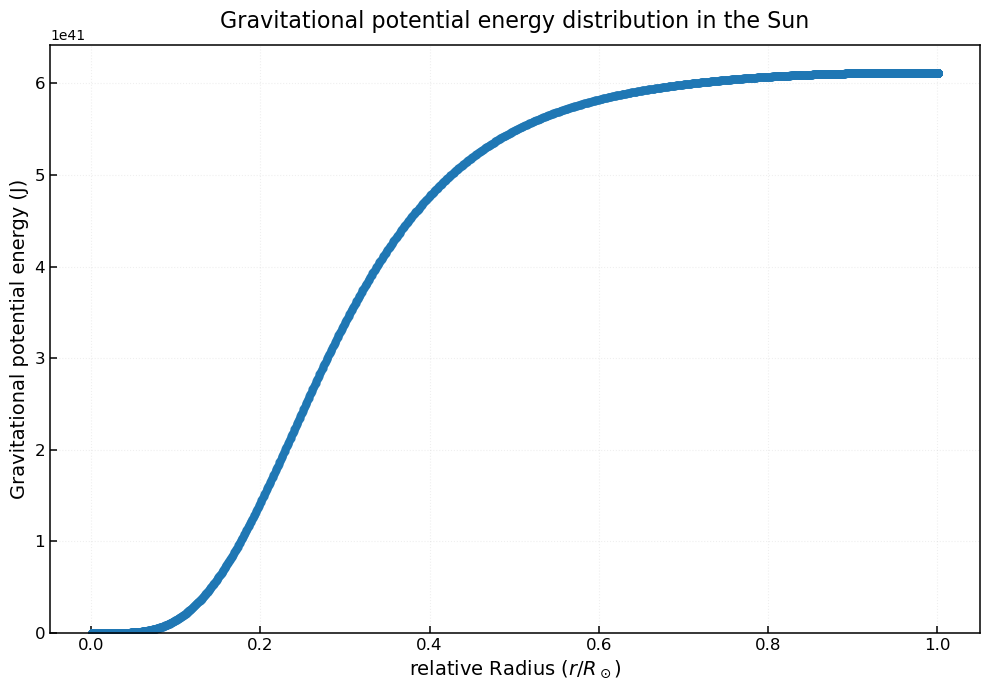

In [21]:
from utilities.ploting import plot_data

data = df.loc[1:][['r/R', 'Omega_absolute']].copy()
data['Omega_absolute'] = data['Omega_absolute'].apply(lambda x: x.value)

plot_data(
    data, 'r/R', 'Omega_absolute' ,
    labels=['Gravitational potential energy enclosed within radius r'], 
    xlabel=r'relative Radius ($r/R_\odot$)', 
    ylabel='Gravitational potential energy (J)', 
    title='Gravitational potential energy distribution in the Sun',
    show_legend = False,
    negative_values = False,
    mirror_axes=False
);



# 2B 2B. Encuentre la cota superior de la fracción de la presión de radiación en el centro de una configuración en equilibrio.
Cambie el parámetro $\mu$ entre valores razonables, incluyendo el caso correspondiente al de la atmósfera solar pero asumiendo el gas totalmente ionizado. Realice un gráfico de $1-\beta_{\star}$ para diversos valores de $M_{\star}/M_{\odot}$ por cada valor del parámetro $\mu$. El corte "0.5" corresponde cuando se igualan las presiones del gas con la de la radiación. ¿Por qué es el límite máximo en el interior estelar? (justificar). Vea las diapositivas de "Teoremas del Equilibrio", proposición 7.


se tiene que la presion para un gas ideal sera $ P = nK_bT = \frac{\mu m_h n}{\mu m_h}k_bT$ lo cual se puede escribir a 
$$
P = \frac{k_b \rho T}{\mu m_h}
$$
donde se puede llegar considerando que todo el gas esta ionizado a  $\mu = \frac{1}{2X+\frac{3}{4}Y + \frac{1}{2}Z}$ donde X es la fracion de masa del hidrogeno, Y la del helio y Z un temino llamado metalicidad que se refiere a las concentraciones de otros elementos

los valores son usualmente deacuerdo con [1] son X = 0.71 y Y = 0.277 de forma que que Z = 0.013 que daria un valor promedio de $\mu = 0.612$, ademas observando la funcion esta podra variar entree 2 (solo otros metales) y 1/2 (solo hidrogeno) 

In [18]:
mu = 1/((0.71*2)+(0.277*(3/4))+(0.013*(1/2))) 
print(f"Mean molecular weight of the solar plasma: mu = {mu:.3f}")

Mean molecular weight of the solar plasma: mu = 0.612


en virtud de la proposiocn 7 define una fracion de presion de radiacion central maxima que puede terner una estrella como $1-\beta_c \le 1-\beta^* $ donde $1-\beta =\frac{P_{rad}}{P_{total}}$
que estara dada por: 
$$
B = \frac{\pi a G^3M_\odot ^2 m^4_h}{18k_b^4}
$$
y que 
$$
\left(\frac{M_*}{M_\odot}\right) B\mu_c^2 = \frac{1-\beta^*}{\beta^{*4} }
$$

esto introduce un porblema donde es necesario resolver una ecuacion cuartica por lo que se toma $(1-\beta^*) = x$ y $K = \left(\frac{M_*}{M_\odot}\right) B\mu_c^2$, con este campo de variable el problema es $f(x) = \frac{x}{(1-x)^4} = K$ que sera monotna creciente para $x\in [0,1]$ de forma que tiene solucion unica por lo que utilizando un la funcion 'brentq' de spicy.optimize se puede encontrar para cada $K$  

In [ ]:
from scipy.optimize import brentq
from utilities.ploting import plot_data
import pandas as pd

# Radiation constant a = 4σ/c  [J m^-3 K^-4]
a_val     = (4 * const.sigma_sb / const.c).si.value
G_val     = const.G.si.value
M_sun_val = const.M_sun.si.value
m_h_val   = const.m_p.si.value   # proton mass ≈ hydrogen atom mass
k_b_val   = const.k_B.si.value

B = (np.pi * a_val * G_val**3 * M_sun_val**2 * m_h_val**4) / (18 * k_b_val**4)
print(f"B = {B:.4e}  (dimensionless)")

# Change of variable x = 1 - β*  =>  (1-β*)/β*^4  =  x/(1-x)^4  =  K
# Standard Eddington result:  K = (M*/M_sun)^2 · B · μ^4
def solve_one_minus_beta(M_ratio, mu):
    K = M_ratio**2 * B * mu**4
    return brentq(lambda x: x / (1 - x)**4 - K, 1e-10, 1 - 1e-10)

masas     = np.linspace(0.1, 60, 500)
mu_values = [0.5, 0.7, 0.612, 1.0, 1.2, 1.5, 2.0]

# Build one dataframe per μ with columns 'M/Msun' and '1-beta'
dfs    = []
labels = []
for mu in mu_values:
    vals  = [solve_one_minus_beta(M, mu) for M in masas]
    df_mu = pd.DataFrame({'M/Msun': masas, '1-beta': vals})
    dfs.append(df_mu)
    labels.append(f'μ = {mu}')

fig = plot_data(
    dfs, 'M/Msun', '1-beta',
    labels=labels,
    xlabel=r'$M_\star \,/\, M_\odot$',
    ylabel=r'$1 - \beta_\star$',
    title='Fracion de Presion central de radiacion maxima ',
    show_legend=True,
    show=False,
    mirror_axes=True,
    line_plot=True,
    negative_values=True
)

ax = fig.axes[0]
ax.axhline(
    0.5, color='black', linestyle='--', linewidth=1.2, alpha=0.7,
    label=r'$\beta_\star = 0.5$ '
)
ax.set_ylim(0, 1)
ax.legend(fontsize=11, frameon=True, fancybox=False, edgecolor='black')
fig.savefig('images/radiation_pressure.png', dpi=100, bbox_inches='tight', facecolor='white')
plt.show()

Como se logra ver en la grafica se tiene que el limite es cuano $\beta_* = 0.5$ lo que implica que la presion de radiacion iguala en magnitud a la presion del gas en el centro, dado a que la prosiicion 7 recae en la suposicion de equilibrio hidrostatico donde se considera a la presion de radiaicion un termino despreciable cuando se llega a este caso el limite el modelo pierde el sentido fisico, ademas llendo por una explicacion fisica con un $beta_c = 0.5$ y sabiendo que la $(1-\beta_c)$ aumenta hacia afuera, esto hace posible que en las capas externas se de una perdida violenta de materia y/o se de una inversion de densidad que rompe el equilibrio hidrostatico de la estrella como se describe en [2]. 

Adicionalmente se ve como para valores de mu altos (alta metalicidad) la presion el limite de la presion central es mas alto, que es de esperarse ya que la alta cantidad de otros elementos (mas pesados) aumentaria la densidad esperada de la estrella permitiendo tener una fraccion de presion de radiacion mayor y viseversa, ademas de que en sentidos practicos cuando se llegan a 60 masas solares el limite para cualquier configuracion es el $0.5$ ya que los limites dados por la prosicion 7 superan este valor.

# referencias 

[1] Christensen-Dalsgaard, J., Däppen, W., Ajukov, S. V., Anderson, E. R., Antia, H. M., Basu, S., Baturin, V. A., Berthomieu, G., Chaboyer, B., Chitre, S. M., Cox, A. N., Demarque, P., Donatowicz, J., Dziembowski, W. A., Gabriel, M., Gough, D. O., Guenther, D. B., Guzik, J. A., Harvey, J. W., Hill, F., Houdek, G., Iglesias, C. A., Kosovichev, A. G., Leibacher, J. W., Morel, P., Proffitt, C. R., Provost, J., Reiter, J., Rhodes Jr., E. J., Rogers, F. J., Roxburgh, I. W., Thompson, M. J., Ulrich, R. K., 1996.
The current state of solar modeling.
Science, 272, 1286 - 1292.

[2] Grassitelli et al., “Subsonic Structure and Optically Thick Winds from Wolf–Rayet Stars.”